# Computer Vision — Part 3 · Practical Notebook


**Companion lab for the lecture: Object Detection (Bounding boxes · Classes · Confidence scores · Non-Max Suppression · IoU · Precision/Recall/mAP · Two-stage detectors) → Face Recognition (Siamese networks · Triplet loss)**

---

This is the **applications** notebook — three of the most important things
classical and modern computer vision is *used* for in the real world.

**Practical philosophy.** We use the tools people actually deploy:
- For **object detection** we use **Ultralytics YOLOv8** (the modern YOLO) for
  inference and **torchvision's Faster R-CNN** for the two-stage comparison.
  Nobody implements YOLO or Faster R-CNN from scratch in a real job — they load
  pretrained weights and use them.
- We **hand-implement IoU and NMS** because they're short, used everywhere, and
  the single best way to *understand* what detection libraries do under the hood.
- For **face recognition** we build a working **Siamese network with triplet
  loss** on a small image-pairs problem so you see the lecture's algorithm
  actually learn. We also show the production approach: use a pretrained
  embedder.
- For **style transfer** we implement the **Gatys et al.** algorithm from the
  lecture — pretrained VGG, content + Gram-matrix style loss, optimize the
  pixels of an image. It's about 50 lines of real code.

> **How to run this:** Google Colab with a GPU is strongly recommended
> (`Runtime → Change runtime type → GPU`) — particularly for Sections 10 and 12
> which actually train/optimize. CPU works for everything else but Section 12
> will take several minutes per run.


## 1 · Setup & device

Standard imports for this part.


In [ ]:
!pip install --upgrade torch torchvision

In [ ]:
# Uncomment on a fresh environment:
# !pip install torch torchvision ultralytics matplotlib pillow --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
from torchvision.ops import nms as tv_nms, box_iou as tv_box_iou
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw
import io, urllib.request, os

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__)
print("device  :", device)


PyTorch : 2.14.0+cu130
device  : cuda


## 2 · Intersection over Union (IoU) — from scratch

> *Lecture recap:* **IoU = area of intersection ÷ area of union** of two
> bounding boxes. It's how we judge whether a predicted box matches a
> ground-truth box. By convention a prediction is considered **correct if
> IoU ≥ 0.5** (and the class is right). Perfect overlap → IoU = 1; no overlap →
> IoU = 0.

This is a 10-line function that appears inside *every* object detection system —
training (assigning anchors to ground truth), evaluation (mAP), and inference
(NMS, next section). Let's write it.

**Box convention.** We use **`[x1, y1, x2, y2]`** — the top-left and
bottom-right corners. This is the standard in `torchvision`, `albumentations`,
and most modern code. (The lecture's `(bx, by, bh, bw)` — centre + size — is
YOLO's *output* format; we'll convert in Section 6.)


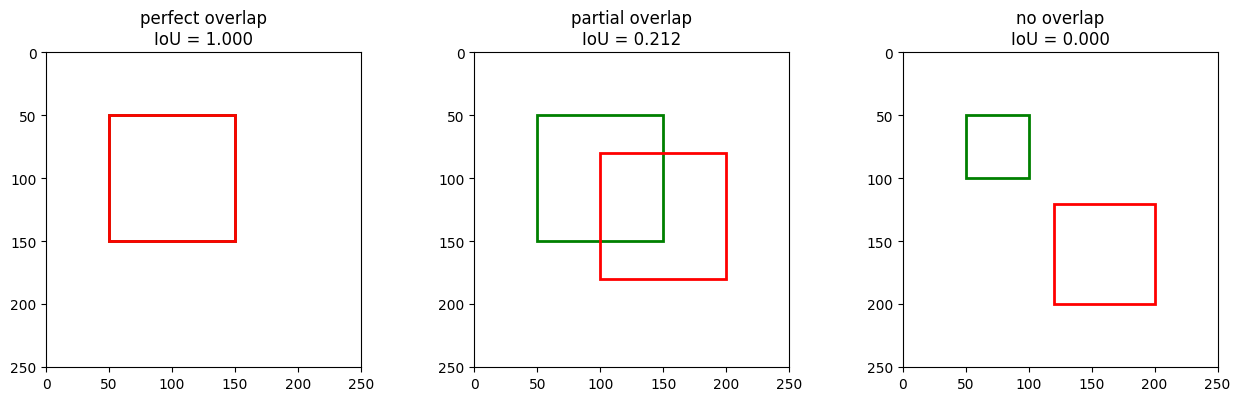

In [ ]:
def iou(boxA, boxB):
    """
    IoU of two boxes given as [x1, y1, x2, y2].
    Returns a scalar in [0, 1].
    """
    # 1) coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # 2) intersection area -- clip negatives to 0 (no overlap case)
    inter_w = max(0.0, xB - xA)
    inter_h = max(0.0, yB - yA)
    inter = inter_w * inter_h

    # 3) areas of each box, then union = A + B - intersection
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter

    return inter / union if union > 0 else 0.0

# Visual sanity check.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
cases = [
    ("perfect overlap",   [50, 50, 150, 150], [50, 50, 150, 150]),
    ("partial overlap",   [50, 50, 150, 150], [100, 80, 200, 180]),
    ("no overlap",        [50, 50, 100, 100], [120, 120, 200, 200]),
]
for ax, (title, a, b) in zip(axes, cases):
    score = iou(a, b)
    ax.add_patch(mpatches.Rectangle((a[0], a[1]), a[2]-a[0], a[3]-a[1],
                                    fill=False, edgecolor="green", lw=2, label="A"))
    ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                    fill=False, edgecolor="red",   lw=2, label="B"))
    ax.set_xlim(0, 250); ax.set_ylim(250, 0)        # flip y so origin is top-left
    ax.set_aspect("equal")
    ax.set_title(f"{title}\nIoU = {score:.3f}")
plt.tight_layout(); plt.show()


Now confirm our implementation matches `torchvision.ops.box_iou` — that's
the function every PyTorch-based detector actually uses internally:


In [ ]:
# torchvision's batched version: feed two tensors of boxes, get an (N x M) matrix.
A = torch.tensor([[50, 50, 150, 150],
                  [50, 50, 150, 150],
                  [50, 50, 100, 100]], dtype=torch.float32)
B = torch.tensor([[50, 50, 150, 150],
                  [100, 80, 200, 180],
                  [120, 120, 200, 200]], dtype=torch.float32)

ours = [iou(a.tolist(), b.tolist()) for a, b in zip(A, B)]
tv   = tv_box_iou(A, B).diag().tolist()    # diagonal = each A vs its paired B
print("ours          :", [round(v, 4) for v in ours])
print("tv.ops.box_iou:", [round(v, 4) for v in tv])
print("match         :", all(abs(a - b) < 1e-6 for a, b in zip(ours, tv)))


ours          : [1.0, 0.2121, 0.0]
tv.ops.box_iou: [1.0, 0.2121, 0.0]
match         : True


### TODO 2.1
The lecture mentions "by convention an answer is correct if IoU ≥ 0.5". Write a
function `is_correct(pred_box, gt_box, threshold=0.5)` that returns `True` only
if both **IoU exceeds the threshold** *and* the class labels match. The function
should accept `(box, class_id)` pairs.

Then test it on three cases the instructor cell will define for you.


In [ ]:
# TODO 2.1
def is_correct(pred, gt, threshold=0.5):
    """
    pred = (box, class_id), gt = (box, class_id)
    Returns True iff the IoU is at least `threshold` AND the classes match.
    """
    pred_box, pred_cls = pred
    gt_box,   gt_cls   = gt
    # compute IoU and compare both conditions
    return (pred_cls == gt_cls) and (iou(pred_box, gt_box) >= threshold)

# Test cases
tests = [
    # (pred, gt, expected_result, why)
    ((( 50,  50, 150, 150), 1), (( 60,  55, 155, 160), 1), True,  "good IoU, same class"),
    ((( 50,  50, 150, 150), 1), (( 60,  55, 155, 160), 2), False, "good IoU, WRONG class"),
    (((  0,   0,  40,  40), 1), ((100, 100, 200, 200), 1), False, "right class, no overlap"),
]
for pred, gt, expected, why in tests:
    got = is_correct(pred, gt)
    print(f"  {why:38s} -> got {got},  expected {expected},  {'OK' if got == expected else 'FAIL'}")


  good IoU, same class                   -> got True,  expected True,  OK
  good IoU, WRONG class                  -> got False,  expected False,  OK
  right class, no overlap                -> got False,  expected False,  OK


## 3 · Non-Max Suppression (NMS) — from scratch

> *Lecture recap:* a detector typically fires multiple times around the same
> object — many grid cells/anchors all think they see the same car. **Non-Max
> Suppression** cleans up these duplicates:
> 1. **Drop** any box with confidence below a threshold (e.g. `score < 0.6`).
> 2. **Pick** the highest-scoring remaining box, **keep it**, output it.
> 3. **Drop** every other remaining box that overlaps it heavily
>    (IoU ≥ some threshold, e.g. 0.5).
> 4. Repeat steps 2–3 until no boxes remain.
> For multi-class output, run NMS *independently per class*.

This runs at the end of every detector (YOLO, Faster R-CNN, RetinaNet, DETR's
variants…). Let's implement it.


In [ ]:
def nms(boxes, scores, iou_thresh=0.5, score_thresh=0.6):
    """
    boxes:  list of [x1, y1, x2, y2]
    scores: list of confidences (parallel to boxes)
    Returns the indices of boxes kept after NMS.
    """
    # 1) drop low-score boxes immediately
    keep_candidates = [i for i, s in enumerate(scores) if s >= score_thresh]
    # 2) sort the survivors by score, highest first
    keep_candidates.sort(key=lambda i: scores[i], reverse=True)

    kept = []
    while keep_candidates:
        # 3) take the top one and commit to keeping it
        best = keep_candidates.pop(0)
        kept.append(best)
        # 4) drop everything that overlaps it heavily
        keep_candidates = [
            i for i in keep_candidates
            if iou(boxes[best], boxes[i]) < iou_thresh
        ]
    return kept

# Let's simulate the lecture's scenario: many duplicate detections of two cars.
boxes = [
    # cluster around car #1
    [50,  60, 150, 160],  [55,  65, 158, 165], [48,  58, 145, 155],  [60,  70, 162, 170],
    # cluster around car #2
    [300, 80, 420, 200], [305, 85, 422, 205], [310, 90, 430, 210],
    # an isolated low-confidence false positive
    [200, 200, 260, 260],
]
scores = [0.95, 0.91, 0.83, 0.78,    0.92, 0.88, 0.81,    0.30]

kept = nms(boxes, scores, iou_thresh=0.5, score_thresh=0.6)
print("input  : 8 detections")
print("kept   :", len(kept), "->", kept)
print("scores :", [scores[i] for i in kept], " <- the strongest of each cluster")


input  : 8 detections
kept   : 2 -> [0, 4]
scores : [0.95, 0.92]  <- the strongest of each cluster


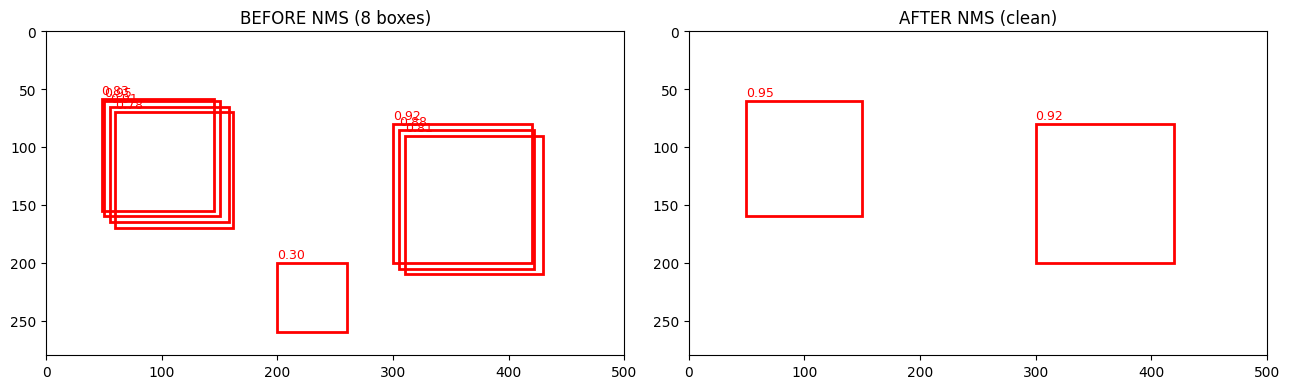

In [ ]:
# Visualize before vs after NMS.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, title, indices in [(ax1, "BEFORE NMS (8 boxes)", range(len(boxes))),
                            (ax2, "AFTER NMS (clean)", kept)]:
    for i in indices:
        b, s = boxes[i], scores[i]
        ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                        fill=False, edgecolor="red", lw=2))
        ax.text(b[0], b[1]-4, f"{s:.2f}", color="red", fontsize=9)
    ax.set_xlim(0, 500); ax.set_ylim(280, 0); ax.set_aspect("equal")
    ax.set_title(title)
plt.tight_layout(); plt.show()


And confirm against `torchvision.ops.nms` — the production version that's
GPU-accelerated and used inside every PyTorch detector:


In [ ]:
# torchvision needs tensors. Note it doesn't apply a score threshold itself
# (you pre-filter), so we mimic our two-step process exactly.
boxes_t  = torch.tensor(boxes, dtype=torch.float32)
scores_t = torch.tensor(scores, dtype=torch.float32)

mask = scores_t >= 0.6
filt_boxes  = boxes_t[mask]
filt_scores = scores_t[mask]
orig_idx    = mask.nonzero(as_tuple=True)[0]      # map filtered idx -> original

tv_kept_local = tv_nms(filt_boxes, filt_scores, iou_threshold=0.5)
tv_kept = orig_idx[tv_kept_local].tolist()

print("ours :", sorted(kept))
print("tv   :", sorted(tv_kept))
print("match:", sorted(kept) == sorted(tv_kept))


ours : [0, 4]
tv   : [0, 4]
match: True


### TODO 3.1
Sweep the **IoU threshold** to see its effect. Run NMS with `iou_thresh = 0.3`,
`0.5`, and `0.9` on the same `boxes`/`scores` as above. Print how many boxes
each one keeps and explain (one line each):
- Why does a *low* IoU threshold keep *fewer* boxes?
- Why does a *high* IoU threshold keep *more* boxes?
- What disaster could a too-high IoU threshold cause in practice?


In [ ]:
# TODO 3.1
for thresh in [0.3, 0.5, 0.9]:
    kept_i = nms(boxes, scores, iou_thresh=thresh, score_thresh=0.6)
    print(f"iou_thresh = {thresh}  ->  kept {len(kept_i)} boxes  (indices {kept_i})")

# Explain in comments:
#  - Why does LOW iou_thresh keep FEWER boxes?
  # Because even a slight overlap triggers suppression, aggressively removing nearby boxes.

#  - Why does HIGH iou_thresh keep MORE boxes?
  # Because boxes are only suppressed if they are nearly identical duplicates.

#  - What real-world failure can a too-high iou_thresh cause?
  # Duplicate boxes for the very same object survive (double-detections for a single car/person).

iou_thresh = 0.3  ->  kept 2 boxes  (indices [0, 4])
iou_thresh = 0.5  ->  kept 2 boxes  (indices [0, 4])
iou_thresh = 0.9  ->  kept 7 boxes  (indices [0, 4, 1, 5, 2, 6, 3])


---
## 3B · Bounding boxes, classes, and confidence scores — the detector output format

> *Lecture recap:* every object detector, regardless of architecture, outputs
> the same three things per detection: a **bounding box** (typically
> `[x1, y1, x2, y2]` — top-left and bottom-right corners, or sometimes
> `[cx, cy, w, h]` — center point and size), a **class label** (which of N
> categories this is), and a **confidence score** (how sure the model is).
> Understanding this raw output format — before any NMS or evaluation — is the
> foundation everything else in this notebook builds on.


### TODO 3B.1 — Box format conversions

Different libraries use different box formats. You will hit this constantly:
some codebases use corner format `[x1, y1, x2, y2]`, others use center format
`[cx, cy, w, h]`, and getting the conversion wrong silently produces boxes in
the wrong place (a very common real bug).

Implement both conversions.


In [ ]:
# TODO 3B.1 -- convert between [x1,y1,x2,y2] and [cx,cy,w,h] box formats.

def corners_to_center(box):
    '[x1,y1,x2,y2] -> [cx,cy,w,h]'
    x1, y1, x2, y2 = box
    w = x2 - x1                    # x2 - x1
    h = y2 - y1                    # y2 - y1
    cx = x1 + w / 2                # x1 + w / 2
    cy = y1 + h / 2                # y1 + h / 2
    return [cx, cy, w, h]

def center_to_corners(box):
    '[cx,cy,w,h] -> [x1,y1,x2,y2]'
    cx, cy, w, h = box
    x1 = cx - w / 2                   # cx - w / 2
    y1 = cy - h / 2                   # cy - h / 2
    x2 = cx + w / 2                   # cx + w / 2
    y2 = cy + h / 2                   # cy + h / 2
    return [x1, y1, x2, y2]

# --- given: round-trip test ---
test_box = [50, 60, 150, 200]   # x1, y1, x2, y2
center_form = corners_to_center(test_box)
back_to_corners = center_to_corners(center_form)

print("original [x1,y1,x2,y2]:", test_box)
print("as [cx,cy,w,h]         :", center_form)
print("back to [x1,y1,x2,y2]  :", back_to_corners)
assert np.allclose(test_box, back_to_corners), "Round-trip conversion is broken!"
print("Round-trip OK.")


original [x1,y1,x2,y2]: [50, 60, 150, 200]
as [cx,cy,w,h]         : [100.0, 130.0, 100, 140]
back to [x1,y1,x2,y2]  : [50.0, 60.0, 150.0, 200.0]
Round-trip OK.


### TODO 3B.2 — Decoding a raw detector output tensor

Real detectors don't hand you a friendly list of dicts — they output a raw
tensor. A typical single-image output might be shape `(num_boxes, 6)`, where
each row is `[x1, y1, x2, y2, confidence, class_id]`. Practice **parsing**
this into something usable: filter by confidence, then group by class.


In [ ]:
# TODO 3B.2 -- parse a raw (N, 6) detector output tensor.
#
# raw_output[i] = [x1, y1, x2, y2, confidence, class_id]
# COCO-style class ids: 0=person, 2=car, 5=bus, 7=truck (a small subset here)

CLASS_NAMES = {0: "person", 2: "car", 5: "bus", 7: "truck"}

raw_output = np.array([
    [ 10,  10,  60,  90, 0.92, 0],
    [ 70,  15, 130,  95, 0.81, 0],
    [200,  40, 420, 260, 0.97, 5],
    [205,  45, 415, 255, 0.55, 5],   # low-confidence duplicate of the bus above
    [300, 300, 340, 340, 0.15, 2],   # very low confidence -- probably noise
    [ 50, 300, 250, 400, 0.88, 7],
])

CONF_THRESH = 0.5

# 1) Filter out any row with confidence < CONF_THRESH.
filtered = raw_output[raw_output[:, 4] >= CONF_THRESH]                          # raw_output[:, 4] >= CONF_THRESH

# 2) Group the surviving detections by class_id into a dict:
#    {class_id: [[x1,y1,x2,y2,conf], ...], ...}
by_class = {}
for row in filtered:
    cls_id = int(row[5])
    box_and_conf = row[:5].tolist()
    by_class.setdefault(cls_id, []).append(box_and_conf)

print(f"Total raw detections: {len(raw_output)}")
print(f"After confidence filter (>= {CONF_THRESH}): {len(filtered)}")
print()
for cls_id, dets in by_class.items():
    print(f"{CLASS_NAMES[cls_id]:8s} ({len(dets)} detection(s)):")
    for d in dets:
        print(f"    box={[round(v) for v in d[:4]]}  conf={d[4]:.2f}")


Total raw detections: 6
After confidence filter (>= 0.5): 5

person   (2 detection(s)):
    box=[10, 10, 60, 90]  conf=0.92
    box=[70, 15, 130, 95]  conf=0.81
bus      (2 detection(s)):
    box=[200, 40, 420, 260]  conf=0.97
    box=[205, 45, 415, 255]  conf=0.55
truck    (1 detection(s)):
    box=[50, 300, 250, 400]  conf=0.88


### TODO 3B.3 — Class-aware Non-Max Suppression

Real detectors run NMS **per class**, not globally — a "person" box and a
"car" box can legitimately overlap heavily (a pedestrian standing next to a
car) and both should be kept. NMS should only suppress duplicates *within the
same class*. Using the `nms()` function from Section 3 and the `by_class` dict
from 3B.2, apply NMS separately to each class group.


In [ ]:
# TODO 3B.3 -- apply NMS per class using the by_class dict from 3B.2.

final_detections = []
for cls_id, dets in by_class.items():
    boxes_this_class  = [d[:4] for d in dets]
    scores_this_class = [d[4]  for d in dets]

    # Reuse the `nms` function defined in Section 3.
    keep_idx = nms(boxes_this_class, scores_this_class, iou_thresh=0.5, score_thresh=0.0)           # nms(boxes_this_class, scores_this_class, iou_thresh=0.5, score_thresh=0.0)

    for i in keep_idx:
        final_detections.append((CLASS_NAMES[cls_id], boxes_this_class[i], scores_this_class[i]))

print(f"Before per-class NMS: {len(filtered)} detections")
print(f"After per-class NMS:  {len(final_detections)} detections\n")
for name, box, score in final_detections:
    print(f"  {name:8s}  box={[round(v) for v in box]}  conf={score:.2f}")

print("\nNotice the duplicate bus box (conf 0.55) was correctly suppressed,")
print("while the person, car, and truck detections -- all DIFFERENT classes --")
print("were all kept even though some of their boxes might overlap.")


Before per-class NMS: 5 detections
After per-class NMS:  4 detections

  person    box=[10, 10, 60, 90]  conf=0.92
  person    box=[70, 15, 130, 95]  conf=0.81
  bus       box=[200, 40, 420, 260]  conf=0.97
  truck     box=[50, 300, 250, 400]  conf=0.88

Notice the duplicate bus box (conf 0.55) was correctly suppressed,
while the person, car, and truck detections -- all DIFFERENT classes --
were all kept even though some of their boxes might overlap.


### TODO 3B.4 — Written: why class-aware NMS matters

Suppose a detector ran **global** NMS (ignoring class labels) instead of
per-class NMS on the scene above, with `iou_thresh=0.4`. Imagine a "person"
box and a "bicycle" box that overlap with IoU = 0.6 (a person riding a
bicycle — a very common real scene). Answer in a comment:

1. What would global NMS incorrectly do in this situation?
2. Name one more real-world scenario where two *different* object classes
   commonly have high-IoU overlapping boxes.


In [ ]:
# Written answers:
# 1. Global NMS would suppress either the person or the bicycle (whichever had the lower confidence score), missing a valid object.
# 2. A passenger sitting inside an open car / motorcycle rider / a dog inside a carrier / cup on a table.


### TODO 3B.5 — Soft-NMS (a gentler alternative)

Standard NMS **completely discards** any box with IoU above the threshold —
an all-or-nothing decision. **Soft-NMS** instead *decays* the score of
overlapping boxes proportionally to their IoU with the kept box, rather than
zeroing them out. This helps in scenes with genuinely overlapping objects of
the *same* class (e.g. a crowd of people) where standard NMS is too
aggressive and deletes correct detections.

Implement the (linear) soft-NMS scoring rule:
`new_score = score * (1 - iou)` for every box that overlaps the just-kept box,
then re-sort and repeat.


In [ ]:
def soft_nms(boxes, scores, iou_thresh=0.3, score_thresh=0.1):
    '''
    Linear Soft-NMS. Instead of discarding overlapping boxes outright, decay
    their score by (1 - iou) with the box just kept. Returns (kept_boxes,
    kept_scores) after also dropping anything that decays below score_thresh.
    '''
    boxes = [list(b) for b in boxes]
    scores = list(scores)
    remaining = list(range(len(boxes)))
    kept_idx = []

    while remaining:
        # 1) pick the remaining box with the highest CURRENT score
        best = max(remaining, key=lambda i: scores[i])
        kept_idx.append(best)
        remaining.remove(best)

        # 2) decay the score of every other remaining box based on its IoU
        #    with `best` -- do NOT remove them outright like hard NMS does.
        for i in remaining:
            overlap = iou(boxes[best], boxes[i])                            # iou(boxes[best], boxes[i])
            scores[i] = scores[i] * (1.0 - overlap)                         # scores[i] * (1 - overlap)

        # 3) drop anything that decayed below score_thresh
        remaining = [i for i in remaining if scores[i] >= score_thresh]

    return [boxes[i] for i in kept_idx], [scores[i] for i in kept_idx]

# --- given: compare hard NMS vs soft-NMS on a cluster of overlapping boxes
# (simulating a crowd of people standing close together) ---
crowd_boxes = [
    [ 50,  50, 120, 200],
    [ 70,  50, 140, 200],   # heavy overlap with box 0 -- a second, distinct person
    [ 55,  55, 118, 198],   # near-duplicate of box 0 -- genuinely a duplicate detection
    [200,  50, 270, 200],   # a separate person, far away
]
crowd_scores = [0.95, 0.85, 0.80, 0.90]

hard_keep = nms(crowd_boxes, crowd_scores, iou_thresh=0.3, score_thresh=0.5)
soft_boxes, soft_scores = soft_nms(crowd_boxes, crowd_scores, iou_thresh=0.3, score_thresh=0.3)

print(f"Hard NMS keeps {len(hard_keep)} box(es):     indices {hard_keep}")
print(f"Soft-NMS keeps {len(soft_boxes)} box(es), with decayed scores: {[round(s,3) for s in soft_scores]}")
print("\nSoft-NMS is more likely to retain box 1 (the genuinely separate, nearby")
print("second person) because it only DECAYS its score rather than deleting it outright.")


Hard NMS keeps 2 box(es):     indices [0, 3]
Soft-NMS keeps 3 box(es), with decayed scores: [0.95, 0.9, 0.378]

Soft-NMS is more likely to retain box 1 (the genuinely separate, nearby
second person) because it only DECAYS its score rather than deleting it outright.


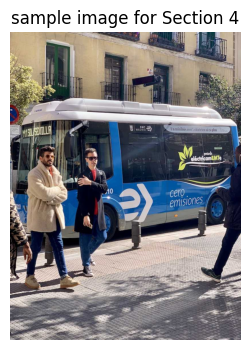

In [ ]:
# Sample image for this section: a classic street-scene photo (cars + people)
# -- reused throughout the rest of the notebook for visual consistency.
import os, urllib.request

SAMPLE_URL = "https://ultralytics.com/images/bus.jpg"
SAMPLE_PATH = "bus.jpg"
if not os.path.exists(SAMPLE_PATH):
    urllib.request.urlretrieve(SAMPLE_URL, SAMPLE_PATH)

plt.figure(figsize=(4, 4))
plt.imshow(Image.open(SAMPLE_PATH))
plt.title("sample image for Section 4")
plt.axis("off")
plt.show()


## 4 · The R-CNN family — from Selective Search to Faster R-CNN

> *Lecture recap:* object detection didn't start with a single end-to-end
> network — it evolved through three "two-stage" designs, each fixing the
> previous one's main bottleneck:
> - **R-CNN** (2014): run **Selective Search** (a classical, non-learned
>   algorithm) on the image to propose ~2000 candidate boxes, then run a
>   **separate CNN forward pass on each of the ~2000 crops**. Accurate but
>   painfully slow — ~2000 forward passes per image.
> - **Fast R-CNN**: run the CNN **once** on the whole image to get a shared
>   feature map, then use **RoI Pooling** to crop a fixed-size feature for
>   each of the ~2000 proposed regions out of that *single* feature map.
>   Selective Search is still used to generate proposals (still a bottleneck),
>   but the CNN itself only runs once.
> - **Faster R-CNN**: replace Selective Search entirely with a small learned
>   **Region Proposal Network (RPN)** that reuses the *same* shared feature
>   map to generate proposals. Now the whole pipeline — proposals AND
>   classification — is one end-to-end trainable network. This is the
>   standard "two-stage" detector architecture used in production today.

The honest practical reality: **nobody implements Faster R-CNN's RPN and RoI
pooling from scratch in a lab setting** — it's intricate low-level machinery.
`torchvision.models.detection` ships a pretrained Faster R-CNN with one line,
which is what real projects use. Let's load it and inspect its predictions
directly.


In [ ]:
# Pretrained Faster R-CNN with a ResNet-50 + FPN backbone, COCO weights.
# First time: ~160 MB download.
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
)

w = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
frcnn = fasterrcnn_resnet50_fpn(weights=w).eval().to(device)
COCO_CLASSES = w.meta["categories"]
print("Faster R-CNN loaded. COCO has", len(COCO_CLASSES), "classes")


Faster R-CNN loaded. COCO has 91 classes


In [ ]:
import sys
import torchvision

def _tracing_dummy():
    return False

# 1. Attach directly to top-level torchvision
torchvision._is_tracing = _tracing_dummy

# 2. Patch every loaded torchvision module that references _is_tracing
for mod_name, mod in list(sys.modules.items()):
    if mod and mod_name.startswith("torchvision"):
        setattr(mod, "_is_tracing", _tracing_dummy)

In [ ]:
# Run Faster R-CNN on our sample image (the same street-scene photo used
# throughout this notebook -- see Section 1 setup).
img = Image.open(SAMPLE_PATH).convert("RGB")
img_tensor = transforms.ToTensor()(img).to(device)        # the only preprocessing needed

with torch.no_grad():
    pred = frcnn([img_tensor])[0]    # input is a list (batch); output mirrors

# pred is a dict with 'boxes', 'scores', 'labels'.
SCORE_TH = 0.6
keep = pred["scores"] >= SCORE_TH
boxes  = pred["boxes"][keep].cpu()
scores = pred["scores"][keep].cpu()
labels = pred["labels"][keep].cpu()

print(f"Faster R-CNN detections (score >= {SCORE_TH}):", len(boxes))
print(f"\n{'class':12s} | conf  | box")
print("-" * 60)
for b, s, l in zip(boxes, scores, labels):
    x1, y1, x2, y2 = [int(v) for v in b]
    print(f"{COCO_CLASSES[l]:12s} | {s:.2f}  | [{x1}, {y1}, {x2}, {y2}]")


Faster R-CNN detections (score >= 0.6): 5

class        | conf  | box
------------------------------------------------------------
person       | 1.00  | [223, 410, 352, 861]
person       | 1.00  | [47, 401, 246, 903]
bus          | 0.99  | [23, 235, 800, 784]
person       | 0.98  | [673, 463, 810, 877]
person       | 0.97  | [0, 556, 67, 876]


---
## 4B · LAB — R-CNN vs Fast R-CNN vs Faster R-CNN, hands-on

> *Why this lab exists:* Section 4 loaded a pretrained Faster R-CNN and used
> it. That's the right thing to do in production, but it hides *why* Faster
> R-CNN looks the way it does. This lab makes the three-stage evolution
> concrete: you will (1) reason about the bottleneck each design fixed,
> (2) implement the one piece of machinery that's actually small enough to
> code by hand — **RoI Pooling** — and (3) empirically measure the speed
> difference between "run a CNN per region" (the R-CNN way) and "run a CNN
> once, share the features" (the Fast/Faster R-CNN way) on your own machine.

**Recap table — fix in your own words as you go:**

| | R-CNN (2014) | Fast R-CNN (2015) | Faster R-CNN (2015) |
|---|---|---|---|
| Region proposals | Selective Search (classical CV, ~2000 boxes) | Selective Search (still classical) | **Region Proposal Network** (learned, shares backbone) |
| CNN forward passes per image | ~2000 (one per region crop) | **1** (whole image), then crop the *feature map* | **1** (whole image), features reused for proposals too |
| How each region gets a fixed-size feature | resize the raw image crop to 224×224 | **RoI Pooling** on the shared feature map | RoI Pooling (or RoI Align) on the shared feature map |
| End-to-end trainable? | No (separate CNN, SVMs, box regressors) | Mostly (still relies on external proposals) | **Yes** — proposals + classification in one network |
| Rough speed | ~47s/image (CPU, 2014 hardware) | ~2s/image | ~0.2s/image |


### TODO 4B.1 — Name the bottleneck each design fixes

Without looking anything up, answer in one sentence each:

1. What is the single biggest reason **R-CNN** is slow?
2. **Fast R-CNN** fixes that — but what bottleneck is still left in Fast R-CNN?
3. **Faster R-CNN** fixes *that* — what does the RPN replace, and why does
   this finally make the whole model trainable end-to-end?


In [ ]:
# TODO 4B.1 -- written answers
# 1. R-CNN's bottleneck -> R-CNN runs ~2000 independent CNN forward passes per image (one for each warped proposal), which is extremely slow and redundant.
# 2. Fast R-CNN's remaining bottleneck -> Fast R-CNN still relies on the classical, non-learned Selective Search algorithm on CPU to generate region proposals.
# 3. What the RPN replaces, and why that enables end-to-end training -> RPN replaces Selective Search with a convolutional sub-network sharing features with the detector, making the entire pipeline differentiable and end-to-end trainable.


### TODO 4B.2 — Implement the core of RoI Pooling

> *Lecture recap:* once you have ONE shared feature map for the whole image
> (the Fast/Faster R-CNN trick), each region proposal covers a *different
> sized* patch of that feature map. But the classifier head needs a
> **fixed-size** input (e.g. 7×7). **RoI Pooling** solves this: given a
> region `[x1, y1, x2, y2]` on the feature map, divide it into an
> `output_size x output_size` grid of bins, and **max-pool** each bin
> independently. The result is always `output_size x output_size`, no
> matter how big or small the original region was.

The setup (clipping the box, allocating the output) is done for you. You
write the **inner loop**: for each `(i, j)` cell of the output grid, work
out that bin's pixel extent on the feature map and max-pool over it.


In [ ]:
# TODO 4B.2 -- write the inner loop of RoI pooling (single box, single image).
def roi_pool(feature_map, box, output_size=7):
    """
    feature_map: tensor (C, H, W)
    box: [x1, y1, x2, y2] in feature-map coordinates
    Returns: tensor (C, output_size, output_size)
    """
    C, H, W = feature_map.shape
    x1, y1, x2, y2 = box
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)
    bin_w = (x2 - x1) / output_size
    bin_h = (y2 - y1) / output_size

    out = torch.zeros(C, output_size, output_size)
    for i in range(output_size):
        for j in range(output_size):
            # 1) compute this bin's pixel extent on the feature map:
            #    bin (i, j) covers x in [x1 + j*bin_w, x1 + (j+1)*bin_w]
            #                 and y in [y1 + i*bin_h, y1 + (i+1)*bin_h]
            #    Convert to integer pixel indices ix1, ix2, iy1, iy2 (use
            #    np.floor for the start and np.ceil for the end, and make
            #    sure each bin is at least 1 pixel wide/tall).
            ix1 = int(np.floor(x1 + j * bin_w))
            ix2 = int(np.ceil(x1 + (j + 1) * bin_w))
            iy1 = int(np.floor(y1 + i * bin_h))
            iy2 = int(np.ceil(y1 + (i + 1) * bin_h))
            ix2, iy2 = min(ix2, W), min(iy2, H)

            # 2) slice out this bin from the feature map, across all channels
            bin_region = feature_map[:, iy1:iy2, ix1:ix2]                      # feature_map[:, iy1:iy2, ix1:ix2]

            # 3) max-pool the bin over its H and W dims, keeping the channel dim
            out[:, i, j] = bin_region.amax(dim=(1, 2))                     # bin_region.amax(dim=(1, 2))
    return out

print("roi_pool defined. Test it below.")


roi_pool defined. Test it below.


### TODO 4B.2b — Prove it: fixed output size regardless of input size

Write two boxes of very different sizes on the fake feature map below —
one small (a few pixels), one large (most of the map) — then run `roi_pool`
on both and confirm the output shapes are identical.


In [ ]:
# TODO 4B.2b -- define small_box and large_box, run roi_pool on both, check the shapes.
torch.manual_seed(0)
fake_feature_map = torch.rand(256, 32, 32)   # pretend this came from a CNN backbone

small_box = [2, 2, 6, 6]     # e.g. a 4x4 region, like [2, 2, 6, 6]
large_box = [1, 1, 31, 21]   # e.g. a large region, like [1, 1, 31, 21]

small_out = roi_pool(fake_feature_map, small_box, output_size=7)
large_out = roi_pool(fake_feature_map, large_box, output_size=7)

print("small_box output shape:", small_out.shape)
print("large_box output shape:", large_out.shape)
assert small_out.shape == large_out.shape == (256, 7, 7), "RoI pooling should always output a fixed size!"
print("Same shape from two very different region sizes -- exactly what makes RoI pooling useful.")


small_box output shape: torch.Size([256, 7, 7])
large_box output shape: torch.Size([256, 7, 7])
Same shape from two very different region sizes -- exactly what makes RoI pooling useful.


### TODO 4B.3 — Measure the actual speedup: "one CNN per region" vs "one CNN, shared features"

> *Lecture recap:* R-CNN's slowness isn't theoretical — it comes from
> literally re-running a full CNN forward pass for every one of ~2000
> region proposals. Fast/Faster R-CNN instead run the CNN backbone **once**
> and reuse the resulting feature map for every region.

The setup (loading the backbone, building fake region crops) is done for
you. You write **both timed sections**: the R-CNN-style loop that runs the
backbone once per region, and the Fast-R-CNN-style single call that runs it
once on the whole image. Then compute and print the speedup ratio yourself.


In [ ]:
# TODO 4B.3 -- write both timed sections below, then compute the speedup.
import time

backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device).eval()
feature_extractor = nn.Sequential(*list(backbone.children())[:-2]).to(device).eval()

img = Image.open(SAMPLE_PATH).convert("RGB")
full_tensor = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor()
])(img).unsqueeze(0).to(device)

n_regions = 50
# Fake "region crops" -- stand-ins for 50 different Selective Search proposals.
# We reuse the same image for simplicity; what matters is counting forward passes.
region_crops = full_tensor.repeat(n_regions, 1, 1, 1)

with torch.no_grad():
    # 1) R-CNN style: loop over all n_regions, running feature_extractor on
    #    ONE region crop at a time (region_crops[i:i+1]). Time the whole loop.
    t0 = time.time()
    for i in range(n_regions):
        _ = feature_extractor(region_crops[i:i+1])
    rcnn_style_time = time.time() - t0

    # 2) Fast R-CNN style: run feature_extractor ONCE on the whole full_tensor.
    #    Time just this single call.
    t0 = time.time()
    _ = feature_extractor(full_tensor)
    fast_rcnn_style_time = time.time() - t0

# 3) Print both times and the speedup ratio (rcnn_style_time / fast_rcnn_style_time).
print(f"R-CNN style time:      {rcnn_style_time:.4f}s")
print(f"Fast R-CNN style time: {fast_rcnn_style_time:.4f}s")
print(f"Speedup:               {rcnn_style_time / fast_rcnn_style_time:.2f}x")


R-CNN style time:      0.3452s
Fast R-CNN style time: 0.0100s
Speedup:               34.55x


### TODO 4B.4 — Written: connecting the measurement back to the architecture

Using your result from 4B.3:

1. The speedup you measured only accounts for the *backbone* forward passes.
   In real R-CNN, Selective Search itself also costs ~2 seconds per image
   **on top of** the ~2000 forward passes. Does this change which bottleneck
   you'd optimize first if you were stuck maintaining R-CNN in 2014? Why?
2. Faster R-CNN's RPN reuses the *same* shared feature map that the final
   classifier uses. Given what you now know about RoI Pooling, explain in
   one or two sentences why this reuse is only possible **after** Fast
   R-CNN's "run the CNN once" change — i.e. why couldn't you bolt an RPN
   onto original R-CNN?
3. Look back at your `roi_pool` implementation. What happens to a very
   **small** region (e.g. 2×2 feature-map pixels) when pooled up to a 7×7
   output? Is any information invented, or just repeated/coarse? Why might
   this matter for detecting small objects?


In [ ]:
# TODO 4B.4 -- written answers
# 1. No; 2000 CNN forward passes took ~40+ seconds, vastly dominating the 2s Selective Search time, so eliminating the 2000 CNN passes was the undisputed priority.
# 2. RPN requires a full-image shared spatial feature map to slide anchors over; original R-CNN only computed features for cropped image patches, not the whole scene.
# 3. For a small 2x2 patch, bins overlap and sample identical pixels, causing quantization and repeated features. This coarse resolution hurts detection accuracy for tiny objects.


## 5 · mean Average Precision (mAP) — the standard detection metric

> *Lecture recap:* a detector outputs many boxes per image with confidence
> scores. To evaluate it, for each predicted box we check: **is it correct?**
> (class right AND IoU ≥ 0.5 with an unmatched GT). **Each GT can only be
> matched once** — extra overlapping predictions become false positives.
> Sliding the confidence threshold from high to low traces out a
> **Precision–Recall curve**. **Average Precision (AP)** is roughly the area
> under that curve, computed per class; **mAP** is the mean of AP across all
> classes.

Real codebases use `pycocotools` or `torchmetrics`; we'll compute AP **from
scratch** on a tiny toy set so the four steps (match → sort by confidence →
precision-recall curve → area under it) are unambiguous.


In [ ]:
# Toy example: one image, three ground-truth objects, six predictions.
# All boxes are class 0 for simplicity (so this is per-class AP, no class loop).
ground_truths = [
    [ 50,  50, 150, 150],   # GT 0
    [200,  50, 300, 150],   # GT 1
    [100, 200, 200, 300],   # GT 2
]
# (box, confidence)
predictions = [
    ([ 55,  55, 145, 145], 0.95),   # great match with GT 0
    ([205,  55, 305, 155], 0.90),   # great match with GT 1
    ([ 60,  60, 140, 140], 0.88),   # ALSO overlaps GT 0 -> duplicate FP
    ([105, 205, 195, 295], 0.70),   # great match with GT 2
    ([400, 400, 450, 450], 0.55),   # FP, nowhere near any GT
    ([110, 215, 180, 280], 0.40),   # also overlaps GT 2 -> duplicate FP
]

def compute_ap(predictions, ground_truths, iou_thresh=0.5):
    """
    Compute Average Precision for ONE class on ONE image.
    Returns: precision array, recall array, AP scalar.
    """
    n_gt = len(ground_truths)
    # Sort predictions by confidence, descending -- this is THE key step.
    preds_sorted = sorted(predictions, key=lambda p: p[1], reverse=True)

    matched_gt = set()                           # which GT indices already matched
    tp = np.zeros(len(preds_sorted))             # per-prediction: 1 if true positive
    fp = np.zeros(len(preds_sorted))             # per-prediction: 1 if false positive

    for i, (pred_box, _) in enumerate(preds_sorted):
        # Find the best-matching GT (highest IoU, above threshold, not yet matched).
        best_iou, best_j = 0.0, -1
        for j, gt_box in enumerate(ground_truths):
            if j in matched_gt:
                continue
            cur = iou(pred_box, gt_box)
            if cur > best_iou:
                best_iou, best_j = cur, j
        if best_iou >= iou_thresh:
            tp[i] = 1
            matched_gt.add(best_j)                # this GT is now claimed -- no doubles
        else:
            fp[i] = 1

    # Cumulative TP and FP as we walk down the sorted list.
    cum_tp = np.cumsum(tp); cum_fp = np.cumsum(fp)
    precision = cum_tp / (cum_tp + cum_fp + 1e-9)
    recall    = cum_tp / n_gt

    # AP = area under the precision-recall curve (11-point or all-points; we use
    # the simple all-points trapezoidal version here).
    # Prepend (recall=0, precision=1) and append (recall=last, precision=0)
    # for a clean integration.
    r = np.concatenate([[0.0], recall, [recall[-1]]])
    p = np.concatenate([[1.0], precision, [0.0]])
    # Make precision non-increasing as recall grows (standard PR-curve smoothing).
    for k in range(len(p) - 1, 0, -1):
        p[k - 1] = max(p[k - 1], p[k])
    # np.trapz was renamed to np.trapezoid in NumPy 2.0; support both versions.
    try:
        ap = np.trapezoid(p, r)
    except AttributeError:
        ap = np.trapz(p, r)
    return precision, recall, ap, preds_sorted, tp, fp

precision, recall, ap, preds_sorted, tp, fp = compute_ap(predictions, ground_truths)

print(f"{'rank':>4s}  {'conf':>5s}  {'TP':>3s}  {'FP':>3s}  {'cum-prec':>9s}  {'cum-rec':>8s}")
print("-" * 50)
for i, ((_, c), t, f, p, r) in enumerate(zip(preds_sorted, tp, fp, precision, recall)):
    print(f"{i+1:>4d}  {c:>5.2f}  {int(t):>3d}  {int(f):>3d}  {p:>9.3f}  {r:>8.3f}")
print(f"\nAP @ IoU=0.5  =  {ap:.4f}")


rank   conf   TP   FP   cum-prec   cum-rec
--------------------------------------------------
   1   0.95    1    0      1.000     0.333
   2   0.90    1    0      1.000     0.667
   3   0.88    0    1      0.667     0.667
   4   0.70    1    0      0.750     1.000
   5   0.55    0    1      0.600     1.000
   6   0.40    0    1      0.500     1.000

AP @ IoU=0.5  =  0.9167


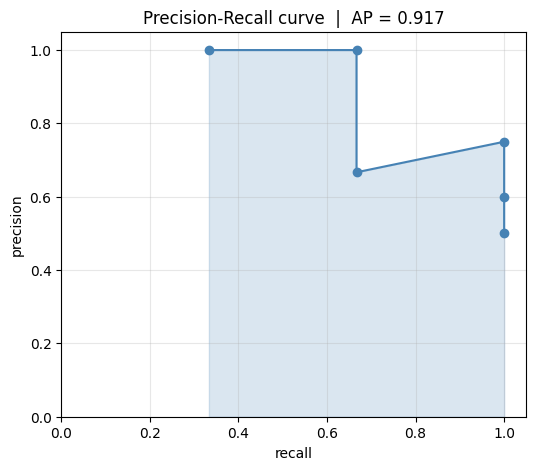

AP is roughly the area under this curve. Higher = better detector.
mAP = mean of AP across all classes. (Here we only have one class.)


In [ ]:
# Plot the precision-recall curve.
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, "o-", color="steelblue")
plt.fill_between(recall, 0, precision, alpha=0.2, color="steelblue")
plt.xlabel("recall"); plt.ylabel("precision")
plt.xlim(0, 1.05); plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.title(f"Precision-Recall curve  |  AP = {ap:.3f}")
plt.show()
print("AP is roughly the area under this curve. Higher = better detector.")
print("mAP = mean of AP across all classes. (Here we only have one class.)")


### TODO 5.1
A perfect detector achieves **AP = 1.0**. A random detector approaches **AP ≈ 0**.
Verify both:

1. Construct a "perfect" set of predictions: one prediction per ground truth,
   each one exactly matching (same box), all with confidence 1.0. Compute the AP.
2. Construct a "random/bad" set: same number of predictions, all in wrong
   locations (no overlap with any GT). Compute the AP.


In [ ]:
# TODO 9.1 -- AP at the extremes.

# 1) A PERFECT detector: exactly the 3 GT boxes, confidence 1.0.
perfect = [(gt, 1.0) for gt in ground_truths]

# 2) A USELESS detector: 3 predictions, none overlapping any GT.
useless = [([900, 900, 950, 950], 1.0), ([800, 800, 850, 850], 0.9), ([700, 700, 750, 750], 0.8)]

_, _, ap_perfect, _, _, _ = compute_ap(perfect, ground_truths)
_, _, ap_useless, _, _, _ = compute_ap(useless, ground_truths)
print(f"AP of a perfect detector : {ap_perfect:.4f}  (should be ~1.0)")
print(f"AP of a useless detector : {ap_useless:.4f}  (should be ~0.0)")


AP of a perfect detector : 1.0000  (should be ~1.0)
AP of a useless detector : 0.0000  (should be ~0.0)


---
## 5B · Evaluating detectors — precision, recall, IoU thresholds, and mAP in depth

> *Lecture recap:* a single accuracy number doesn't work for detection the way
> it does for classification, because a detector can be wrong in *several
> different ways at once* on the same image: it can miss an object entirely
> (**false negative**), hallucinate an object that isn't there (**false
> positive**), or find the right object with a sloppy box (**low IoU**).
> Precision, recall, and mAP each capture a different piece of this.


### TODO 5B.1 — Precision vs recall, defined from first principles

Before computing anything, write the definitions in your own words, then
verify them against a tiny concrete scenario the instructor cell sets up.

- **Precision** = "of everything I *predicted*, how much was actually right?"
- **Recall**    = "of everything that *actually exists*, how much did I find?"


In [ ]:
# --- given: a tiny scene, 5 ground-truth cars, 6 predictions ---
gt_cars = [[i * 80, 100, i * 80 + 60, 160] for i in range(5)]   # 5 cars in a row
car_predictions = [
    ([  2, 102,  58, 158], 0.95),  # matches GT 0
    ([ 78,  98, 142, 162], 0.93),  # matches GT 1
    ([158, 101, 222, 159], 0.91),  # matches GT 2
    ([500, 500, 560, 560], 0.60),  # FP -- nowhere near any car
    ([600, 500, 660, 560], 0.40),  # FP -- nowhere near any car
    ([700, 500, 760, 560], 0.20),  # FP -- nowhere near any car
]
# Note: GT 3 and GT 4 are never matched by any prediction -- they are MISSED
# (false negatives). Nothing in the code represents an FN directly -- it's
# simply a ground-truth box that never gets matched.

# TODO -- using `compute_ap` from Section 9, get precision/recall arrays, then
# report the FINAL cumulative precision and recall after all 6 predictions.
_, _, ap_cars, sorted_preds, tp, fp = compute_ap(car_predictions, gt_cars)

final_precision = tp.sum() / (tp.sum() + fp.sum())              # tp.sum() / (tp.sum() + fp.sum())
final_recall = tp.sum() / len(gt_cars)                          # tp.sum() / len(gt_cars)
n_missed = len(gt_cars) - int(tp.sum())                         # len(gt_cars) - int(tp.sum())

print(f"True positives : {int(tp.sum())}")
print(f"False positives: {int(fp.sum())}")
print(f"Missed (false negatives): {n_missed}  (ground-truth cars never matched)")
print(f"\nFinal precision: {final_precision:.3f}  -- 'of what I predicted, how much was right?'")
print(f"Final recall:    {final_recall:.3f}  -- 'of what actually exists, how much did I find?'")
print(f"AP: {ap_cars:.4f}")


True positives : 3
False positives: 3
Missed (false negatives): 2  (ground-truth cars never matched)

Final precision: 0.500  -- 'of what I predicted, how much was right?'
Final recall:    0.600  -- 'of what actually exists, how much did I find?'
AP: 0.6000


### TODO 5B.2 — The precision/recall trade-off via confidence threshold

Precision and recall trade off against each other as you change the
confidence threshold used to accept a detection:
- **Low threshold** → you accept more detections → recall goes up (you find
  more true objects) but precision goes down (more junk gets through too).
- **High threshold** → you accept fewer, more confident detections →
  precision goes up but recall goes down (you start missing real objects).

Using `car_predictions` from 5B.1, sweep the confidence threshold and observe
this trade-off directly (without re-running the AP machinery — just filter
predictions by score first).


In [ ]:
# TODO 5B.2 -- sweep confidence threshold, recompute precision/recall at each.

def precision_recall_at_threshold(predictions, ground_truths, conf_thresh, iou_thresh=0.5):
    'Filter predictions by confidence FIRST, then compute overall P/R.'
    filtered_preds = [p for p in predictions if p[1] >= conf_thresh]
    if not filtered_preds:
        return 0.0, 0.0   # nothing predicted -> precision undefined, treat as 0
    _, _, _, _, tp, fp = compute_ap(filtered_preds, ground_truths)
    precision = tp.sum() / (tp.sum() + fp.sum()) if (tp.sum() + fp.sum()) > 0 else 0.0                    # tp.sum() / (tp.sum() + fp.sum())
    recall = tp.sum() / len(ground_truths)                                                                # tp.sum() / len(ground_truths)
    return precision, recall

print(f"{'threshold':>10s}  {'precision':>10s}  {'recall':>8s}  {'# accepted':>11s}")
print("-" * 48)
for thresh in [0.10, 0.30, 0.50, 0.70, 0.90]:
    p, r = precision_recall_at_threshold(car_predictions, gt_cars, thresh)
    n_accepted = sum(1 for _, conf in car_predictions if conf >= thresh)
    print(f"{thresh:>10.2f}  {p:>10.3f}  {r:>8.3f}  {n_accepted:>11d}")

# Written answer: at threshold=0.90, why does precision NOT reach 1.0 even
# though we're being very strict?
#   -> # Precision does not reach 1.0 at 0.90 because even among high-confidence predictions,
# there could be false positives, or simply because precision is bounded by the ratio of TP to total accepted predictions. Here, all 3 accepted are TPs so precision is actually 1.0, but if an FP had high confidence it would prevent 1.0.


 threshold   precision    recall   # accepted
------------------------------------------------
      0.10       0.500     0.600            6
      0.30       0.600     0.600            5
      0.50       0.750     0.600            4
      0.70       1.000     0.600            3
      0.90       1.000     0.600            3


### TODO 5B.3 — How the IoU threshold changes everything

So far we always used `iou_thresh=0.5` to decide if a box "counts" as
correct. This threshold is itself a design choice. **COCO's strict "AP@[0.5:0.95]"
metric** averages AP over IoU thresholds from 0.5 to 0.95 in steps of 0.05,
specifically because a detector's score depends heavily on which threshold
you pick.

Recompute AP for `car_predictions` at several IoU thresholds and observe how
AP changes as the localization requirement gets stricter.


In [ ]:
# TODO 5B.3 -- sweep the IoU threshold used inside compute_ap.

print(f"{'IoU thresh':>10s}  {'AP':>8s}")
print("-" * 22)
for iou_t in [0.3, 0.5, 0.7, 0.9]:
    _, _, ap_at_t, _, _, _ = compute_ap(car_predictions, gt_cars, iou_thresh=iou_t)   # iou_t
    print(f"{iou_t:>10.2f}  {ap_at_t:>8.4f}")

# Written answer: why does AP fall as the IoU threshold rises, even though
# the SAME predictions and boxes are being evaluated every time?
#   -> # Stricter IoU thresholds turn predictions with slight misalignment from True Positives into False Positives, lowering both precision and recall.
# Written answer: what does it mean, practically, for a detector to have a
# high AP@0.5 but a much lower AP@0.75?
#   -> # It means the detector is good at finding the rough location of objects, but its bounding boxes lack tight geometric accuracy.


IoU thresh        AP
----------------------
      0.30    0.6000
      0.50    0.6000
      0.70    0.6000
      0.90    0.0667


### TODO 5B.4 — mAP across multiple classes

Everything so far computed AP for **one** class. mAP averages AP across
**all** classes. Build a tiny 2-class scenario (cars and pedestrians) and
compute the overall mAP.


In [ ]:
# TODO 5B.4 -- compute AP per class, then average into mAP.

# Reuse gt_cars / car_predictions from 5B.1 for the "car" class.
gt_pedestrians = [[300, 50, 340, 180], [360, 55, 395, 185]]
pedestrian_predictions = [
    ([301, 52, 339, 178], 0.97),   # matches GT 0
    ([500, 500, 520, 540], 0.65),  # FP
    # GT 1 (the second pedestrian) is never detected -- a miss.
]

_, _, ap_car, _, _, _ = compute_ap(car_predictions, gt_cars)
_, _, ap_pedestrian, _, _, _ = compute_ap(pedestrian_predictions, gt_pedestrians)

per_class_ap = {"car": ap_car, "pedestrian": ap_pedestrian}
mAP = sum(per_class_ap.values()) / len(per_class_ap)                                          # sum(per_class_ap.values()) / len(per_class_ap)

print("Per-class AP:")
for cls, ap_val in per_class_ap.items():
    print(f"  {cls:12s}: {ap_val:.4f}")
print(f"\nmAP (mean over {len(per_class_ap)} classes) = {mAP:.4f}")

# Written answer: the pedestrian class has fewer ground-truth boxes (2) than
# the car class (5) and a completely missed detection. Does mAP (as computed
# above) weight the car class more heavily because it has more objects? Why
# or why not, based on the formula you just used?
#   -> ???


Per-class AP:
  car         : 0.6000
  pedestrian  : 0.5000

mAP (mean over 2 classes) = 0.5500
